In [ ]:
!pip install emoji
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# read sample data from csv
file_path = '/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_review_data_binned.csv'
df_review_data_binned = pd.read_csv(file_path)

# Null value checking
print(df_review_data_binned.isnull().sum())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.8 MB/s eta 0:00:00
Mounted at /content/drive
review_id         0
user_id           0
business_id       0
stars             0
useful            0
funny             0
cool              0
text              0
date              0
stars_business    0
stars_binned      0
dtype: int64


In [ ]:
# Pre-processing
import emoji
import re
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
df_review_data_binned = df_review_data_binned.dropna(subset=['stars_binned'])
print(df_review_data_binned.shape)

# Identify if there are any emoji characters

def contains_emoji(text):
  if text is None:
    return False

  return emoji.emoji_count(text) > 0

def clean_text(text):
  if text is None:
    return ""
  text = emoji.replace_emoji(text, replace='')
  # convert to lower case
  text = text.lower()
  # remove strings that start with http
  text = re.sub(r'http\S+', '', text)
  # remove HTML tags
  text = re.sub(r'<.*?>', '', text)
  # remove special characters
  text = re.sub(r'www\S+', '', text)
  # remove punctuations
  text = re.sub(r'[^\w\s]', '', text)
  # remove numbers
  text = re.sub(r'\d+', '', text)
  text = unicodedata.normalize('NFKD', text)
  text = text.encode('ascii', 'ignore').decode('utf-8')
  #remove any left non-ascii characters
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

df_review_data_binned["text"] = df_review_data_binned["text"].apply(clean_text)
# download stopwords
nltk.download('stopwords')
# download tokenizer data
nltk.download('punkt')
# remove stopwords
stop_words = set(stopwords.words('english'))
# remove stopwords from text column
df_review_data_binned['text'] = df_review_data_binned['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
# perform lemitazation
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
# download lexical database
nltk.download('wordnet')
# multilingual lexical database
nltk.download('omw-1.4')
# perform lemmatization
df_review_data_binned['text'] = df_review_data_binned['text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))




(411589, 11)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# TfidfVectorizer (from sklearn.feature_extraction.text) converts raw text into numerical feature vectors using the TF-IDF weighting scheme.
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    min_df=5, # ignore words that appear in < 5 documents,
    max_df=0.8, # ignore words that appear in > 80% of the documents,
    max_features=10000,
    ngram_range=(1, 2))
corpus = df_review_data_binned['text']

X = vectorizer.fit_transform(corpus)
print(type(X))
print(X.shape)



<class 'scipy.sparse._csr.csr_matrix'>
(411589, 10000)


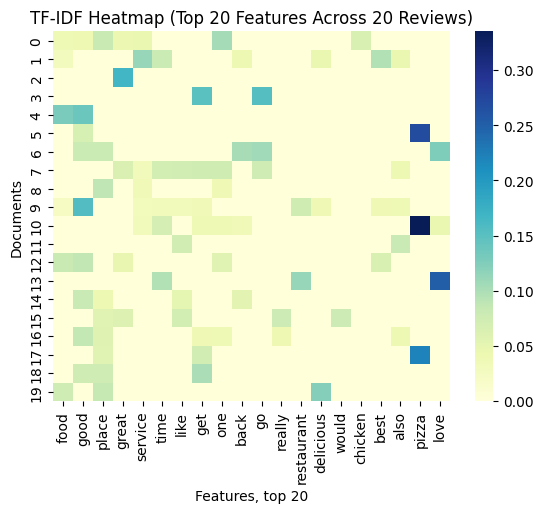

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Plot heatmap of top 20 features
#Sum TF-IDF scores for each feature across all documents
feature_sums = np.array(X.sum(axis=0)).flatten()
feature_names = np.array(vectorizer.get_feature_names_out())

# Create a pandas Series and sort
top_features = pd.Series(feature_sums, index=feature_names).sort_values(ascending=False).head(20)

# Select top features to plot
top_feature_indices = [vectorizer.vocabulary_[f] for f in top_features.index]
X_top = X[:, top_feature_indices].toarray()[:20]  # first 20 docs

# Plot heatmap
sns.heatmap(X_top, cmap="YlGnBu", xticklabels=top_features.index)
plt.title("TF-IDF Heatmap (Top 20 Features Across 20 Reviews)")
plt.xlabel("Features, top 20")
plt.ylabel("Documents")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2

# Define target variable (ensure it's discrete)
y = df_review_data_binned['stars_binned']
y = pd.Series(y).astype('category').cat.codes

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# number of features to select from the data sample
k = 1000 if X_train.shape[1] > 1000 else X_train.shape[1]

# Mutual Information feature selection
selector = SelectKBest(score_func=chi2, k=k)
X_train_chi2_selection = selector.fit_transform(X_train, y_train)
X_test_chi2_selection  = selector.transform(X_test)
# selected features
selected_features = feature_names[selector.get_support()]
print(f"Selected features (k): {X_train_chi2_selection.shape[1]}")
print(f"Shapes -> Train: {X_train_chi2_selection.shape}, Test: {X_test_chi2_selection.shape}")



Selected features (k): 1000
Shapes -> Train: (329271, 1000), Test: (82318, 1000)


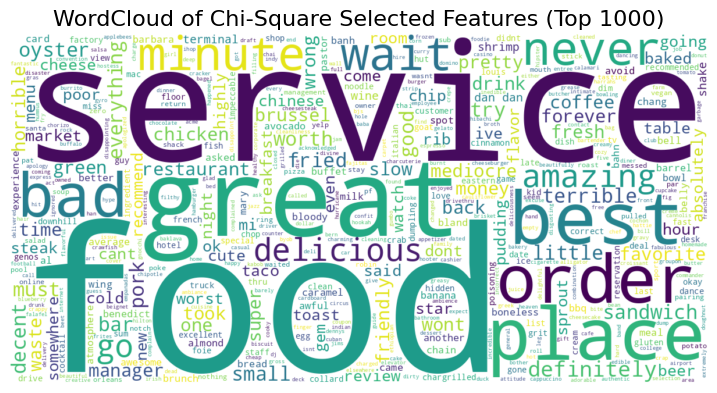

In [ ]:
from wordcloud import WordCloud

selected_text = " ".join(selected_features)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=500,
    random_state=42
).generate(selected_text)

# Plot
plt.figure(figsize=(9, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Chi-Square Selected Features (Top 1000)", fontsize=16)
plt.show()


Evaluation Metrics

Logistic Regression Accuracy: 0.3987949172720426

Classification Report:
               precision    recall  f1-score   support

           0      0.354     0.624     0.452     11810
           1      0.324     0.280     0.301     19221
           2      0.544     0.277     0.367     33784
           3      0.387     0.613     0.474     17503

    accuracy                          0.399     82318
   macro avg      0.402     0.448     0.398     82318
weighted avg      0.432     0.399     0.386     82318

Macro F1-score: 0.39838935847124524
Weighted F1-score: 0.3864394107311468


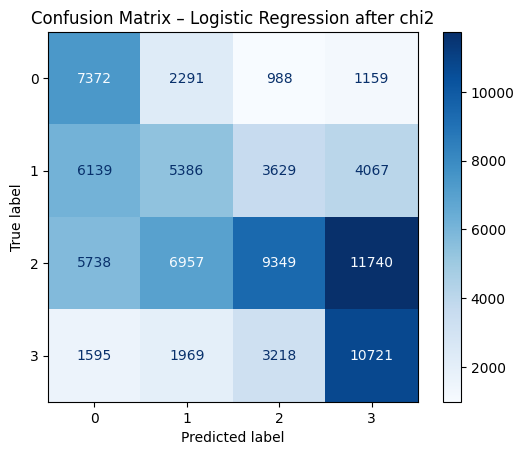

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Train classifier (Logistic Regression)
logistic_regression = LogisticRegression(max_iter=2000,
                         n_jobs=-1,
                         solver="saga",
                         class_weight = 'balanced')
logistic_regression.fit(X_train_chi2_selection, y_train)

y_pred = logistic_regression.predict(X_test_chi2_selection)

print("\nEvaluation Metrics\n")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
print("Macro F1-score:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1-score:", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression after chi2")
plt.show()




Evaluation Metrics Multinomial Naive Bayes

Multinomial Naive Bayes Accuracy: 0.4391263150222309
Classification report:
               precision    recall  f1-score   support

           0       0.58      0.19      0.29     11810
           1       0.39      0.03      0.05     19221
           2       0.43      0.96      0.59     33784
           3       0.65      0.04      0.08     17503

    accuracy                           0.44     82318
   macro avg       0.52      0.31      0.25     82318
weighted avg       0.49      0.44      0.32     82318

Macro F1-score: 0.25475157569232015
Weighted F1-score: 0.31515509980454304


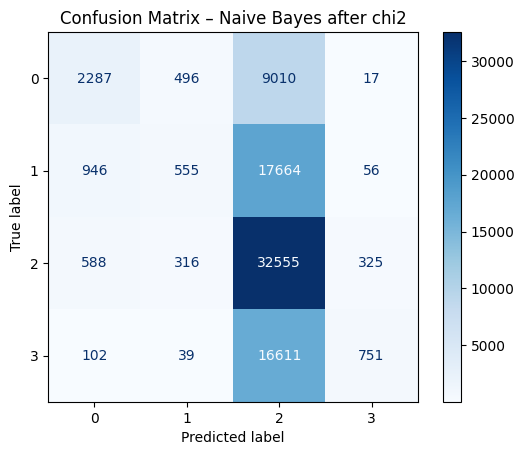

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train_chi2_selection, y_train)

# Predictions and evaluation
y_pred = nb.predict(X_test_chi2_selection)

print("\nEvaluation Metrics Multinomial Naive Bayes\n")
print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Macro F1-score:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1-score:", f1_score(y_test, y_pred, average='weighted'))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Naive Bayes after chi2")
plt.show()




Evaluation Metrics Decision Tree


Decision Tree Accuracy: 0.4193007604655118
Classification report:               precision    recall  f1-score   support

           0       0.58      0.19      0.29     11810
           1       0.39      0.03      0.05     19221
           2       0.43      0.96      0.59     33784
           3       0.65      0.04      0.08     17503

    accuracy                           0.44     82318
   macro avg       0.52      0.31      0.25     82318
weighted avg       0.49      0.44      0.32     82318

Macro F1-score: 0.25475157569232015
Weighted F1-score: 0.31515509980454304


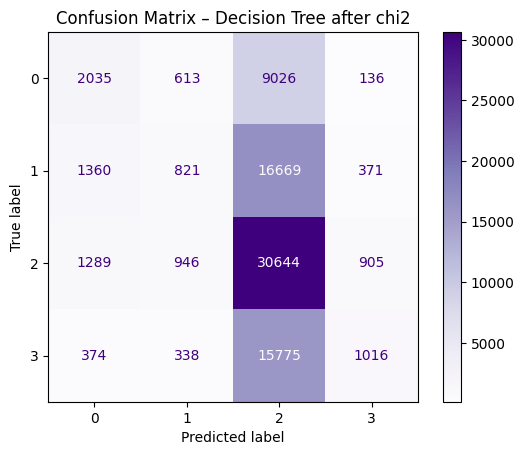

In [ ]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="gini",   # or "entropy"
    max_depth=20,       # keep it from overfitting on text
    min_samples_leaf=5, # smooth leaves a bit
    random_state=42
)
dt.fit(X_train_chi2_selection, y_train)
y_pred_dt = dt.predict(X_test_chi2_selection)


print("\nEvaluation Metrics Decision Tree\n")
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification report:", classification_report(y_test, y_pred))
print("Macro F1-score:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1-score:", f1_score(y_test, y_pred, average='weighted'))

# Confusion matrix for the tree
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title("Confusion Matrix – Decision Tree after chi2")
plt.show()


Evaluation Metrics Random Forest

Randon Forest Accuracy: 0.44744770281104984
Classification report:
               precision    recall  f1-score   support

           0       0.58      0.19      0.29     11810
           1       0.39      0.03      0.05     19221
           2       0.43      0.96      0.59     33784
           3       0.65      0.04      0.08     17503

    accuracy                           0.44     82318
   macro avg       0.52      0.31      0.25     82318
weighted avg       0.49      0.44      0.32     82318

Macro F1-score: 0.25475157569232015
Weighted F1-score: 0.31515509980454304


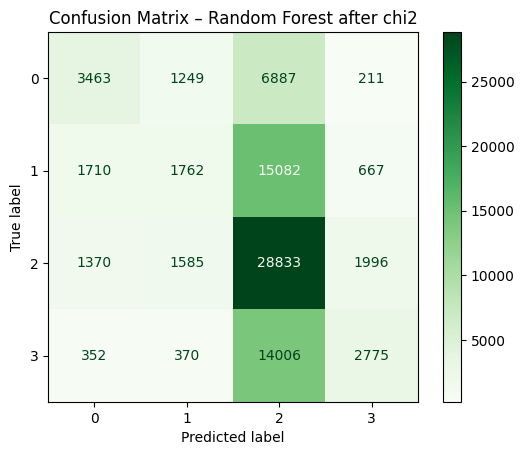

In [ ]:
# Random forest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight = 'balanced',
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_chi2_selection, y_train)
y_pred_rf = rf.predict(X_test_chi2_selection)
print("\nEvaluation Metrics Random Forest\n")
print("Randon Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Macro F1-score:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1-score:", f1_score(y_test, y_pred, average='weighted'))

# optional: confusion matrix for RF
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix – Random Forest after chi2")
plt.show()